<a href="https://colab.research.google.com/github/RecursionAndIteration/AIcourse/blob/main/KlasyfikacjaBinarna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

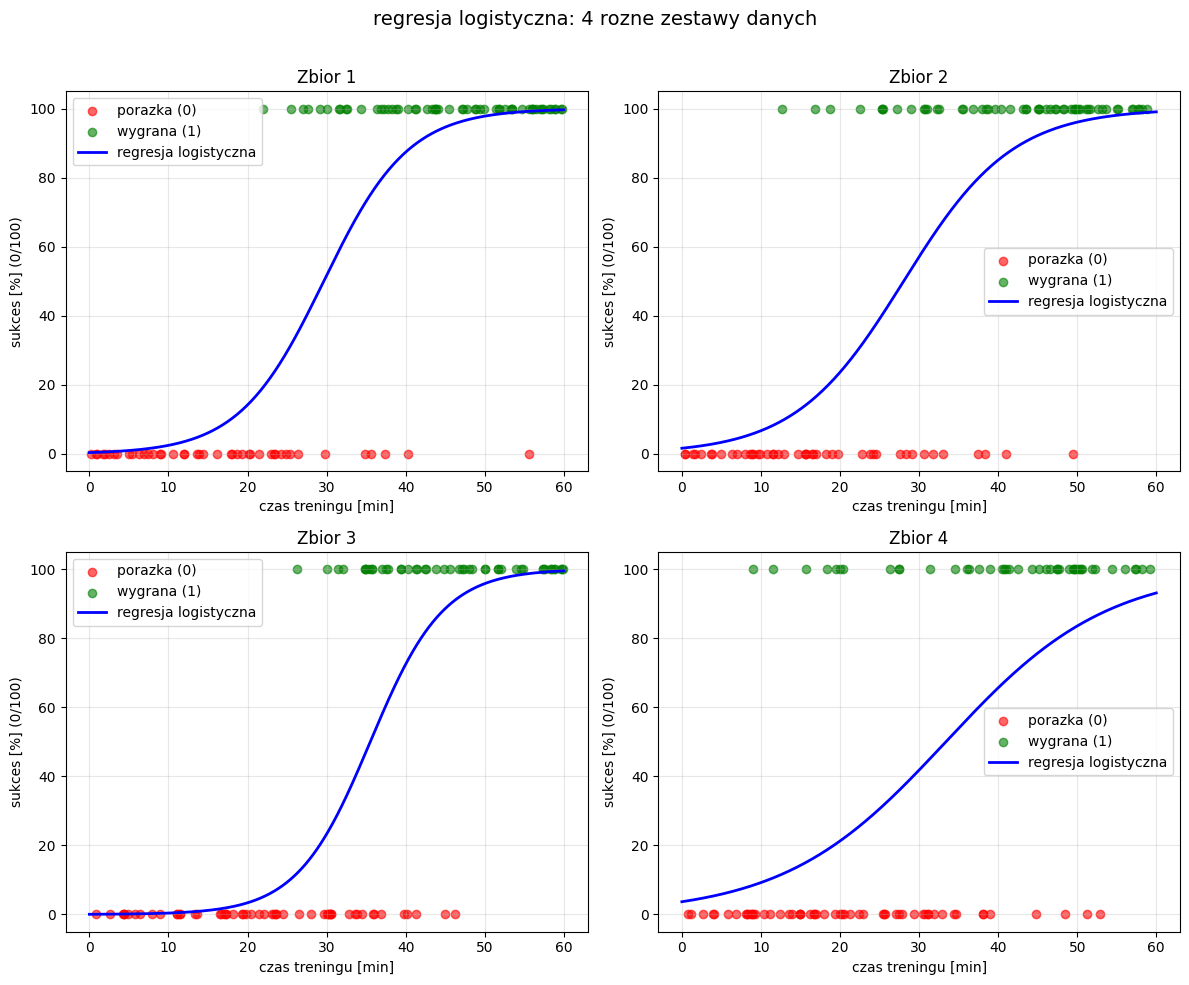

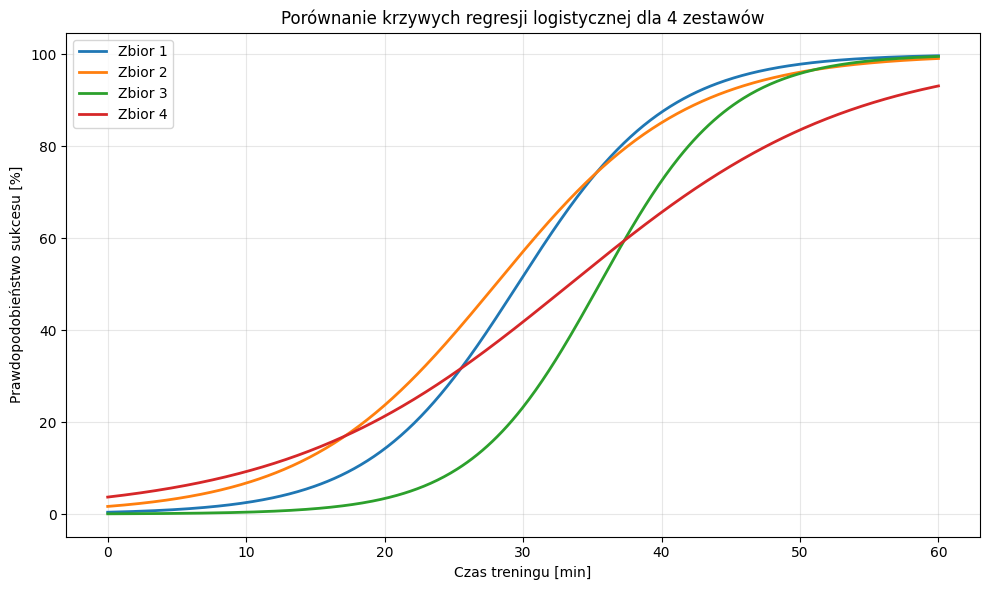

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import pandas as pd

def generuj_zbiory(n, seed, k_true, x0_true):
    rng = np.random.default_rng(seed)
    czas = rng.uniform(0,60,n)
    prawd = 1/(1+np.exp(-k_true * (czas - x0_true)))
    wynik = rng.binomial(1,prawd)
    return czas,wynik

zbiory = [
    {"n":100,"seed":0, "k_true":0.2, "x0_true":30, "etykieta":"Zbior 1"},
    {"n":100,"seed":1, "k_true":0.15, "x0_true":25, "etykieta":"Zbior 2"},
    {"n":100,"seed":100, "k_true":0.25, "x0_true":35, "etykieta":"Zbior 3"},
    {"n":100,"seed":10, "k_true":0.1, "x0_true":40, "etykieta":"Zbior 4"},
]

siatka = np.linspace(0,60,500).reshape(-1,1)
#[1,2,3,4,5] --> [[1],[2],[3],[4],[5]]
fig,axs = plt.subplots(2,2, figsize=(12,10))
axs = axs.ravel()
krzywe=[]

for i,zbior in enumerate(zbiory):
  czas,wynik = generuj_zbiory(zbior["n"],zbior["seed"],zbior["k_true"],zbior["x0_true"])
  x = czas.reshape(-1,1)
  model = LogisticRegression()
  model.fit(x,wynik)

  przewidziane = model.predict_proba(siatka)[:,1]*100
  krzywe.append((przewidziane,zbior["etykieta"]))

  axs[i].scatter(czas[wynik==0],wynik[wynik==0]*100, c="red", alpha=0.6, label="porazka (0)")
  axs[i].scatter(czas[wynik==1],wynik[wynik==1]*100, c="green", alpha=0.6, label="wygrana (1)")


  axs[i].plot(siatka,przewidziane,"b-",linewidth=2,label="regresja logistyczna")
  axs[i].set_title(zbior["etykieta"])
  axs[i].set_xlabel("czas treningu [min]")
  axs[i].set_ylabel("sukces [%] (0/100)")
  axs[i].grid(True, alpha=0.3)
  axs[i].legend()

plt.suptitle("regresja logistyczna: 4 rozne zestawy danych", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

plt.figure(figsize=(10,6))
for przewidziane, etykieta in krzywe:
  plt.plot(siatka,przewidziane,linewidth=2,label=etykieta)
plt.xlabel("Czas treningu [min]")
plt.ylabel("Prawdopodobieństwo sukcesu [%]")
plt.title("Porównanie krzywych regresji logistycznej dla 4 zestawów")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
modele=[]
modele = []
for zb in zbiory:
 czas, y = generuj_zbiory(zb["n"], zb["seed"], zb["k_true"],zb["x0_true"])
 X = czas.reshape(-1, 1)
 clf = LogisticRegression()
 clf.fit(X, y)
 modele.append((zb["etykieta"], clf))


czasy_testowe = [5, 10, 15, 20, 25, 30, 40, 45, 50, 55]
X_test = np.array(czasy_testowe, dtype=float).reshape(-1, 1)
kolumny = ["czas [min]"]
wiersze = [[t] for t in czasy_testowe]

for etykieta, clf in modele:
 proba = clf.predict_proba(X_test)[:, 1]
 proba_proc = np.round(proba * 100, 1)
 kolumny += [f"{etykieta}[%]"]
 for i in range(len(wiersze)):
  wiersze[i] += [proba_proc[i],]

df = pd.DataFrame(wiersze, columns=kolumny)
df

,czas [min],Zbior 1[%],Zbior 2[%],Zbior 3[%],Zbior 4[%]
0,5,1.0,3.4,0.1,5.9
1,10,2.5,6.7,0.4,9.2
2,15,6.1,13.0,1.2,14.2
3,20,14.2,23.7,3.4,21.3
4,25,29.6,39.1,9.3,30.6
5,30,51.7,57.1,23.3,41.8
6,40,87.4,85.1,72.4,65.6
7,45,94.6,92.2,88.6,75.7
8,50,97.8,96.1,95.8,83.5
9,55,99.1,98.1,98.5,89.2
